UGV BATTLEFIELD PATH PLANNING
Battlefield Size: 70 x 70 km
Each grid cell represents 1 km x 1 km

Enter coordinates between 0 and 69
Example: Start = (0, 0), Goal = (69, 69)

Enter Start X: 0
Enter Start Y: 0
Enter Goal X: 69
Enter Goal Y: 69

Low Density
Obstacle Density: 10.0 %
Path Found: YES
Shortest Distance: 138 km
Nodes Explored: 4449
Execution Time: 0.014637 seconds


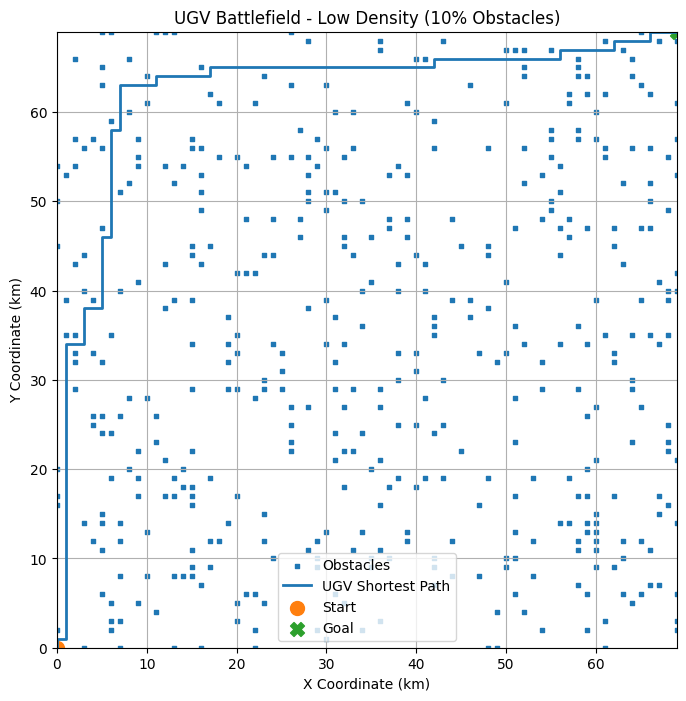


Medium Density
Obstacle Density: 20.0 %
Path Found: YES
Shortest Distance: 138 km
Nodes Explored: 3908
Execution Time: 0.012457 seconds


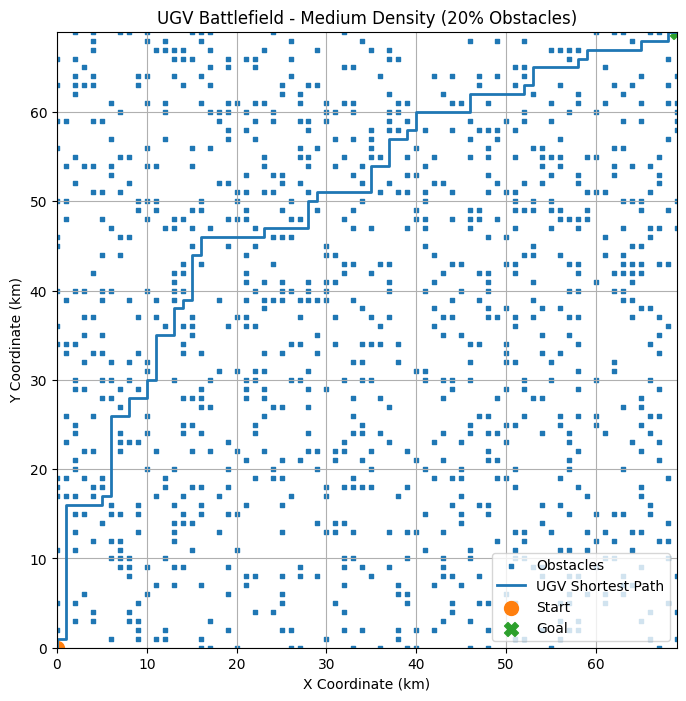


High Density
Obstacle Density: 30.0 %
Path Found: NO
No path available for this obstacle arrangement.
Nodes Explored: 2
Execution Time: 3e-05 seconds


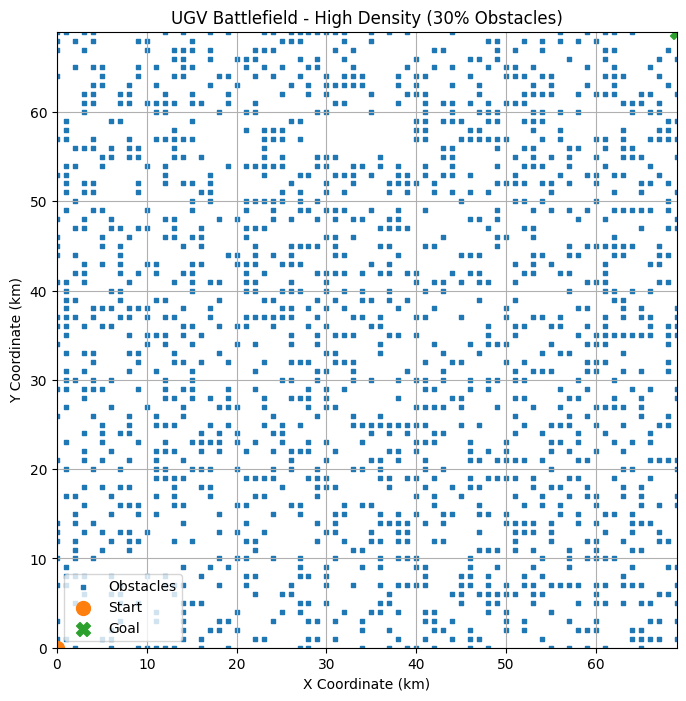



MEASURES OF EFFECTIVENESS (MOE)
Density           Obstacle %     Distance (km)     Nodes Explored    Time (sec)     Success   
-------------------------------------------------------------------------------------
Low Density       10             138               4449              0.014637       Yes       
Medium Density    20             138               3908              0.012457       Yes       
High Density      30             -                 2                 0.000030       No        

UGV PATH PLANNING COMPLETED SUCCESSFULLY.


In [1]:
# ============================================================
# UGV PATH PLANNING ON A 70 x 70 KM BATTLEFIELD GRID
# Programming Assignment - Question 2
# ============================================================

import random
import time
import heapq
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Battlefield size
# ------------------------------------------------------------
ROWS = 70
COLS = 70

print("UGV BATTLEFIELD PATH PLANNING")
print("Battlefield Size: 70 x 70 km")
print("Each grid cell represents 1 km x 1 km")
print()

# ------------------------------------------------------------
# 2. User input for Start and Goal
# ------------------------------------------------------------
print("Enter coordinates between 0 and 69")
print("Example: Start = (0, 0), Goal = (69, 69)")
print()

sx = int(input("Enter Start X: "))
sy = int(input("Enter Start Y: "))

gx = int(input("Enter Goal X: "))
gy = int(input("Enter Goal Y: "))

start = (sx, sy)
goal = (gx, gy)

if not (0 <= sx < ROWS and 0 <= sy < COLS and
        0 <= gx < ROWS and 0 <= gy < COLS):
    raise ValueError("Coordinates must be between 0 and 69.")

# ------------------------------------------------------------
# 3. Generate random obstacles
# ------------------------------------------------------------
density_levels = {
    "Low Density": 0.10,
    "Medium Density": 0.20,
    "High Density": 0.30
}

# ------------------------------------------------------------
# 4. Generate battlefield grid
# ------------------------------------------------------------
def generate_grid(density):
    grid = [[0 for _ in range(COLS)] for _ in range(ROWS)]

    for i in range(ROWS):
        for j in range(COLS):
            if random.random() < density:
                grid[i][j] = 1       # 1 = obstacle

    # Start and goal must always be free
    grid[start[0]][start[1]] = 0
    grid[goal[0]][goal[1]] = 0

    return grid

# ------------------------------------------------------------
# 5. Find shortest path using BFS
# ------------------------------------------------------------
def bfs(grid, start, goal):

    queue = [start]
    visited = {start}
    parent = {start: None}

    explored = 0

    directions = [
        (-1, 0),   # Up
        (1, 0),    # Down
        (0, -1),   # Left
        (0, 1)     # Right
    ]

    while queue:

        current = queue.pop(0)
        explored += 1

        if current == goal:
            break

        x, y = current

        for dx, dy in directions:

            nx = x + dx
            ny = y + dy

            if 0 <= nx < ROWS and 0 <= ny < COLS:

                next_node = (nx, ny)

                if grid[nx][ny] == 0 and next_node not in visited:

                    visited.add(next_node)
                    parent[next_node] = current
                    queue.append(next_node)

    # --------------------------------------------------------
    # Reconstruct shortest path
    # --------------------------------------------------------
    if goal not in parent:
        return None, explored

    path = []
    current = goal

    while current is not None:
        path.append(current)
        current = parent[current]

    path.reverse()

    return path, explored

# ------------------------------------------------------------
# 6. Run the UGV for all three obstacle densities
# ------------------------------------------------------------
results = []

for level, density in density_levels.items():

    print("\n" + "=" * 60)
    print(level)
    print("Obstacle Density:", density * 100, "%")
    print("=" * 60)

    # Generate battlefield
    grid = generate_grid(density)

    # Measure execution time
    start_time = time.perf_counter()

    path, explored = bfs(grid, start, goal)

    end_time = time.perf_counter()

    execution_time = end_time - start_time

    # --------------------------------------------------------
    # Calculate Measures of Effectiveness
    # --------------------------------------------------------
    if path is not None:

        # Each movement is 1 km
        distance = len(path) - 1

        success = "Yes"

        print("Path Found: YES")
        print("Shortest Distance:", distance, "km")
        print("Nodes Explored:", explored)
        print("Execution Time:", round(execution_time, 6), "seconds")

        results.append([
            level,
            density * 100,
            distance,
            explored,
            execution_time,
            success
        ])

    else:

        distance = None
        success = "No"

        print("Path Found: NO")
        print("No path available for this obstacle arrangement.")
        print("Nodes Explored:", explored)
        print("Execution Time:", round(execution_time, 6), "seconds")

        results.append([
            level,
            density * 100,
            "-",
            explored,
            execution_time,
            success
        ])

    # --------------------------------------------------------
    # 7. Visualize battlefield and UGV path
    # --------------------------------------------------------
    plt.figure(figsize=(8, 8))

    # Draw obstacles
    obstacle_x = []
    obstacle_y = []

    for i in range(ROWS):
        for j in range(COLS):
            if grid[i][j] == 1:
                obstacle_x.append(j)
                obstacle_y.append(i)

    plt.scatter(
        obstacle_x,
        obstacle_y,
        marker="s",
        s=10,
        label="Obstacles"
    )

    # Draw path
    if path is not None:

        path_x = [p[1] for p in path]
        path_y = [p[0] for p in path]

        plt.plot(
            path_x,
            path_y,
            linewidth=2,
            label="UGV Shortest Path"
        )

    # Start and goal
    plt.scatter(
        start[1],
        start[0],
        s=100,
        marker="o",
        label="Start"
    )

    plt.scatter(
        goal[1],
        goal[0],
        s=100,
        marker="X",
        label="Goal"
    )

    plt.title(
        "UGV Battlefield - " + level +
        " (" + str(int(density * 100)) + "% Obstacles)"
    )

    plt.xlabel("X Coordinate (km)")
    plt.ylabel("Y Coordinate (km)")
    plt.xlim(0, 69)
    plt.ylim(0, 69)
    plt.grid(True)
    plt.legend()
    plt.show()

# ------------------------------------------------------------
# 8. Display Measures of Effectiveness
# ------------------------------------------------------------
print("\n")
print("=" * 85)
print("MEASURES OF EFFECTIVENESS (MOE)")
print("=" * 85)

print(
    f"{'Density':<18}"
    f"{'Obstacle %':<15}"
    f"{'Distance (km)':<18}"
    f"{'Nodes Explored':<18}"
    f"{'Time (sec)':<15}"
    f"{'Success':<10}"
)

print("-" * 85)

for result in results:

    level, density, distance, explored, execution_time, success = result

    print(
        f"{level:<18}"
        f"{density:<15.0f}"
        f"{str(distance):<18}"
        f"{explored:<18}"
        f"{execution_time:<15.6f}"
        f"{success:<10}"
    )

print("\nUGV PATH PLANNING COMPLETED SUCCESSFULLY.")